In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns

%matplotlib inline
plt.style.use('tableau-colorblind10')

pd.set_option('display.precision', 2)


In [2]:
#look at first file
df = pd.read_csv(filepath_or_buffer="../data/raw/iea-hydrogen-production-projects-database/projects.csv")
display(df.head(10))

,Unnamed: 0,Ref,Project name,Country,Date online,Decomission date,Status,Technology,Technology_details,Technology_electricity,...,Capacity_MWel,Capacity_Nm³ H₂/h,Capacity_kt H2/y,Capacity_t CO₂ captured/y,IEA zero-carbon estimated normalized capacity [Nm³ H₂/hour],References,Latitude,Longitude,Technology_aggregate,LOWE_CF
0,0,NaN,Other projects from confidential sources (post...,NaN,NaN,NaN,Other,NG w CCUS,NaN,NaN,...,NaN,3.54e+06,2756.77,NaN,0.00e+00,NaN,NaN,NaN,Fossil fuels with CCUS,NaN
1,1,NaN,Other projects from confidential sources (post...,NaN,NaN,NaN,Other,Other,Various types,NaN,...,NaN,6.26e+05,487.72,NaN,0.00e+00,NaN,NaN,NaN,Other,NaN
2,2,NaN,Other projects from confidential sources (post...,NaN,NaN,NaN,Other,Other Electrolysis,Various types,NaN,...,17443.88,3.88e+06,3022.21,NaN,3.88e+06,NaN,NaN,NaN,Electrolysis,NaN
3,3,NaN,Other projects from confidential sources (2000...,NaN,NaN,NaN,Operational,PEM,NaN,NaN,...,6.54,1.26e+03,0.98,NaN,1.26e+03,NaN,NaN,NaN,Electrolysis,NaN
4,4,NaN,Other projects from confidential sources (2000...,NaN,NaN,NaN,Operational,ALK,NaN,NaN,...,141.76,3.08e+04,24.03,NaN,3.08e+04,NaN,NaN,NaN,Electrolysis,NaN
5,5,NaN,Non-energy related projects (2000-2024),NaN,NaN,NaN,Operational,ALK & PEM,NaN,NaN,...,78.39,NaN,NaN,NaN,0.00e+00,NaN,NaN,NaN,Electrolysis,NaN
6,6,NaN,Non-energy related projects (post-2024),NaN,NaN,NaN,Other,ALK,NaN,NaN,...,46.56,NaN,NaN,NaN,0.00e+00,NaN,NaN,NaN,Electrolysis,NaN
7,7,3.0,H2GO Energy Park Oude-Tonge - 1st phase,NLD,2025.0,NaN,FID/Construction,Other Electrolysis,Unknown PtX,Dedicated renewable,...,2.50,5.56e+02,0.43,NaN,5.56e+02,[503][630][609],51.70,4.16,Electrolysis,0.50
8,8,4.0,H2GO Energy Park Oude-Tonge - 2nd phase,NLD,2030.0,NaN,Concept,Other Electrolysis,Unknown PtX,Dedicated renewable,...,23.50,5.22e+03,4.07,NaN,5.22e+03,[503][630][609],51.70,4.16,Electrolysis,0.50
9,9,5.0,"NortH2, phase 1",NLD,2030.0,NaN,Feasibility study,Other Electrolysis,Unknown PtX,Dedicated renewable,...,4000.00,8.89e+05,693.01,NaN,8.89e+05,[379],53.47,6.63,Electrolysis,0.55


In [3]:
#look at second file
df2 = pd.read_csv(filepath_or_buffer="../data/raw/iea-hydrogen-production-projects-database/references.csv")
df2.head(10)

#this file is not neccessary for the data analysis itself

,Number,Reference
0,1,Energieinstitut an der Johannes Kepler Univers...
1,2,European Power-to-Gas platform - Power-to-Gas ...
2,3,"Bailera et al., 2017. Power to Gas projects re..."
3,4,"F. Smeets and D. Thomas, 2017, HyBALANCE : sta..."
4,5,"G. Gahleitner, 2013. Hydrogen from renewable e..."
5,6,"M. Gotz et al, 2015. Renewable Power-to-Gas: A..."
6,7,"Master’s Thesis - Vesa Vartiainen, 2016. SCREE..."
7,8,Alkaline vs PEM electrolysers: lessons learnt ...
8,9,Global screening of projects and technologies ...
9,10,Energiepark Mainz: Technical and economic anal...


In [4]:
#check df out
print("shape: ", df.shape)
print("---")
print("columns: ", df.columns)
print("---")
display(df.dtypes)
print("----")
display("describe: ", df.describe())
print(print("----"))
print("NaN-Values: ", df.isna().sum())

shape:  (2441, 37)
---
columns:  Index(['Unnamed: 0', 'Ref', 'Project name', 'Country', 'Date online',
       'Decomission date', 'Status', 'Technology', 'Technology_details',
       'Technology_electricity', 'Technology_electricity_details', 'Product',
       'EndUse_Refining', 'EndUse_Ammonia', 'EndUse_Methanol',
       'EndUse_Iron&Steel', 'EndUse_Other Ind', 'EndUse_Mobility',
       'EndUse_Power', 'EndUse_Grid inj.', 'EndUse_CHP',
       'EndUse_Domestic heat', 'EndUse_Biofuels', 'EndUse_Synfuels',
       'EndUse_CH4 grid inj.', 'EndUse_CH4 mobility', 'Announced Size',
       'Capacity_MWel', 'Capacity_Nm³ H₂/h', 'Capacity_kt H2/y',
       'Capacity_t CO₂ captured/y',
       'IEA zero-carbon estimated normalized capacity [Nm³ H₂/hour]',
       'References', 'Latitude', 'Longitude', 'Technology_aggregate',
       'LOWE_CF'],
      dtype='object')
---


Unnamed: 0                                                       int64
Ref                                                            float64
Project name                                                    object
Country                                                         object
Date online                                                    float64
Decomission date                                               float64
Status                                                          object
Technology                                                      object
Technology_details                                              object
Technology_electricity                                          object
Technology_electricity_details                                  object
Product                                                         object
EndUse_Refining                                                float64
EndUse_Ammonia                                                 float64
EndUse

----


'describe: '

,Unnamed: 0,Ref,Date online,Decomission date,EndUse_Refining,EndUse_Ammonia,EndUse_Methanol,EndUse_Iron&Steel,EndUse_Other Ind,EndUse_Mobility,...,EndUse_CH4 grid inj.,EndUse_CH4 mobility,Capacity_MWel,Capacity_Nm³ H₂/h,Capacity_kt H2/y,Capacity_t CO₂ captured/y,IEA zero-carbon estimated normalized capacity [Nm³ H₂/hour],Latitude,Longitude,LOWE_CF
count,2441.0,2434.00,1879.00,114.00,154.0,422.0,168.0,108.0,427.0,696.0,...,75.0,20.0,2024.00,2.15e+03,2160.00,1.02e+02,2.42e+03,2434.00,2434.00,2433.00
mean,1220.0,1745.65,2024.08,2016.28,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,528.99,1.25e+05,97.27,1.52e+06,1.05e+05,27.28,11.87,0.55
std,704.8,876.59,6.27,6.89,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2084.41,4.65e+05,361.60,2.14e+06,4.24e+05,28.78,61.70,0.16
min,0.0,3.00,1965.00,2004.00,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,0.00,1.15e-02,0.00,1.20e-01,0.00e+00,-54.11,-155.56,0.30
25%,610.0,1013.50,2023.00,2013.00,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,2.00,5.56e+02,0.43,4.70e+05,1.92e+02,0.00,-3.70,0.50
50%,1220.0,1822.50,2025.00,2016.00,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,32.28,9.62e+03,7.50,1.00e+06,4.68e+03,38.06,3.57,0.55
75%,1830.0,2485.75,2027.00,2019.00,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,280.00,7.29e+04,57.40,1.70e+06,5.77e+04,51.07,24.26,0.57
max,2440.0,3160.00,2043.00,2063.00,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,41574.27,9.24e+06,7202.88,1.50e+07,9.24e+06,71.11,178.45,0.90


----
None
NaN-Values:  Unnamed: 0                                                        0
Ref                                                               7
Project name                                                      0
Country                                                           7
Date online                                                     562
Decomission date                                               2327
Status                                                            9
Technology                                                        1
Technology_details                                              816
Technology_electricity                                          297
Technology_electricity_details                                 1066
Product                                                          16
EndUse_Refining                                                2287
EndUse_Ammonia                                                 2019
EndUse_Methanol          

In [5]:
#delete  unneccessary columns

del df["Unnamed: 0"]
del df["Ref"]

In [6]:
#display(sns.pairplot(df))

In [7]:
#check which countries are listed
df["Country"].unique()

array([nan, 'NLD', 'NOR', 'SWE', 'ESP', 'USA', 'JPN', 'CHE', 'DEU', 'GBR',
       'DNK', 'AUT', 'CHN', 'CAN', 'EST', 'FRA', 'MYS', 'AUS', 'POL',
       'FIN', 'SGP', 'THA', 'ITA', 'CRI', 'CHL', 'BEL', 'IND', 'GRC',
       'ISL', 'TUR', 'ARG', 'IRN', 'NZL', 'PRT', 'LBN', 'MRT', 'PRT\nESP',
       'SAU', 'ROM\nDEU\nAUT', 'POL\nCZE\nSVK\nHUN', 'COK', 'ZAF', 'ARE',
       'OMN', 'URY', 'PRY', 'ESP\nFRA', 'KOR', 'MAR', 'ALB', 'IDN', 'BRB',
       'TTO', 'BGD', 'BRA', 'HUN', 'TWN', 'MEX', 'VNM', 'SVN', 'CZE',
       'SVK', 'DEU\nDNK', 'LTU', 'LVA', 'IRL', 'PER', 'RUS', 'COL', 'KAZ',
       'EGY', 'ZWE', 'NAM', 'KEN', 'BWA', 'PAK', 'COD', 'AGO', 'UKR',
       'BGR', 'LUX', 'ROU', 'LKA', 'NER', 'DJI', 'UZB', 'PAN', 'MNG',
       'DMA', 'JOR', 'MOZ', 'DOM', 'QAT', 'SRB', 'PHL', 'FJI', 'UGA',
       'CYP', 'HRV', 'TUN', 'DZA', 'BHR', 'ISR'], dtype=object)

In [8]:
#have a proper look at the first seven project, which have no information about location
#also use this to have a look at the columns not displayed before, therefore increasing to 10 lines
with pd.option_context('display.max_columns', None):
    print(df.iloc[0:10, :])

#the first seven lines do not contain sufficient information to be counted as reliable source and will therefore be deleted

                                        Project name Country  Date online  \
0  Other projects from confidential sources (post...     NaN          NaN   
1  Other projects from confidential sources (post...     NaN          NaN   
2  Other projects from confidential sources (post...     NaN          NaN   
3  Other projects from confidential sources (2000...     NaN          NaN   
4  Other projects from confidential sources (2000...     NaN          NaN   
5            Non-energy related projects (2000-2024)     NaN          NaN   
6            Non-energy related projects (post-2024)     NaN          NaN   
7            H2GO Energy Park Oude-Tonge - 1st phase     NLD       2025.0   
8            H2GO Energy Park Oude-Tonge - 2nd phase     NLD       2030.0   
9                                    NortH2, phase 1     NLD       2030.0   

   Decomission date             Status          Technology Technology_details  \
0               NaN              Other           NG w CCUS             

In [9]:
df = df.dropna(axis=0, subset=['Country'])  #deleting the lines without location information

df.shape

(2434, 35)

In [10]:
#look at the different answers per column and the amount of those to better understand how to analyse the columns data
cols = ['Project name', 'Country', 'Date online',
       'Decomission date', 'Status', 'Technology', 'Technology_details',
       'Technology_electricity', 'Technology_electricity_details', 'Product',
       'EndUse_Refining', 'EndUse_Ammonia', 'EndUse_Methanol',
       'EndUse_Iron&Steel', 'EndUse_Other Ind', 'EndUse_Mobility',
       'EndUse_Power', 'EndUse_Grid inj.', 'EndUse_CHP',
       'EndUse_Domestic heat', 'EndUse_Biofuels', 'EndUse_Synfuels',
       'EndUse_CH4 grid inj.', 'EndUse_CH4 mobility', 'Announced Size',
       'Capacity_MWel', 'Capacity_Nm³ H₂/h', 'Capacity_kt H2/y',
       'Capacity_t CO₂ captured/y',
       'IEA zero-carbon estimated normalized capacity [Nm³ H₂/hour]',
       'References', 'Latitude', 'Longitude', 'Technology_aggregate',
       'LOWE_CF']
for column in cols:
    print(len(df[column].unique()), "{}: ".format(column), df[column].unique())
    print("-----------------------------------------------")


2409 Project name:  ['H2GO Energy Park Oude-Tonge - 1st phase'
 'H2GO Energy Park Oude-Tonge - 2nd phase' 'NortH2, phase 1' ...
 'H2 hub Bintulu Sarawak ' "Nujio'qonik Green Hydrogen -phase 4"
 'Green Hydrogen Hub Stuttgart (GH2S)']
-----------------------------------------------
102 Country:  ['NLD' 'NOR' 'SWE' 'ESP' 'USA' 'JPN' 'CHE' 'DEU' 'GBR' 'DNK' 'AUT' 'CHN'
 'CAN' 'EST' 'FRA' 'MYS' 'AUS' 'POL' 'FIN' 'SGP' 'THA' 'ITA' 'CRI' 'CHL'
 'BEL' 'IND' 'GRC' 'ISL' 'TUR' 'ARG' 'IRN' 'NZL' 'PRT' 'LBN' 'MRT'
 'PRT\nESP' 'SAU' 'ROM\nDEU\nAUT' 'POL\nCZE\nSVK\nHUN' 'COK' 'ZAF' 'ARE'
 'OMN' 'URY' 'PRY' 'ESP\nFRA' 'KOR' 'MAR' 'ALB' 'IDN' 'BRB' 'TTO' 'BGD'
 'BRA' 'HUN' 'TWN' 'MEX' 'VNM' 'SVN' 'CZE' 'SVK' 'DEU\nDNK' 'LTU' 'LVA'
 'IRL' 'PER' 'RUS' 'COL' 'KAZ' 'EGY' 'ZWE' 'NAM' 'KEN' 'BWA' 'PAK' 'COD'
 'AGO' 'UKR' 'BGR' 'LUX' 'ROU' 'LKA' 'NER' 'DJI' 'UZB' 'PAN' 'MNG' 'DMA'
 'JOR' 'MOZ' 'DOM' 'QAT' 'SRB' 'PHL' 'FJI' 'UGA' 'CYP' 'HRV' 'TUN' 'DZA'
 'BHR' 'ISR']
------------------------------------------

In [11]:
mask = (df.loc[:, 'Status'] != 'Concept') & (df.loc[:, 'Status'] != 'Feasibility study') & (df.loc[:, 'Status'] != 'Decommisioned')
df_real = df.loc[mask, :]
df_real

,Project name,Country,Date online,Decomission date,Status,Technology,Technology_details,Technology_electricity,Technology_electricity_details,Product,...,Capacity_MWel,Capacity_Nm³ H₂/h,Capacity_kt H2/y,Capacity_t CO₂ captured/y,IEA zero-carbon estimated normalized capacity [Nm³ H₂/hour],References,Latitude,Longitude,Technology_aggregate,LOWE_CF
7,H2GO Energy Park Oude-Tonge - 1st phase,NLD,2025.0,NaN,FID/Construction,Other Electrolysis,Unknown PtX,Dedicated renewable,Others/Various,H2,...,2.50,555.56,4.33e-01,NaN,555.56,[503][630][609],51.70,4.16,Electrolysis,0.50
10,Norsk e-Fuel Phase 1,NOR,2028.0,NaN,FID/Construction,SOEC,NaN,Dedicated renewable,Others/Various,Synfuels,...,50.26,13227.26,1.03e+01,NaN,13227.26,[414] [521][1288][1449] [1693],65.84,13.20,Electrolysis,0.50
12,HYBRIT pilot,SWE,2021.0,NaN,Operational,ALK,NaN,Grid,NaN,H2,...,4.50,978.26,7.63e-01,NaN,978.26,[299] [340] [434] [576] [2224],65.59,22.16,Electrolysis,0.57
13,HYBRIT demo,SWE,2025.0,NaN,FID/Construction,ALK,NaN,Grid,NaN,H2,...,500.00,108695.65,8.47e+01,NaN,108695.65,[299] [340][1108],65.59,22.16,Electrolysis,0.57
14,Iberdrola - Puertollano I,ESP,2022.0,NaN,Operational,PEM,NaN,Dedicated renewable,Solar PV,Ammonia,...,20.00,3846.15,3.00e+00,NaN,3846.15,[567] [572][620][631],38.67,-4.05,Electrolysis,0.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2397,Rorvik hydrogen hub,NOR,2027.0,NaN,FID/Construction,Other Electrolysis,Unknown PtX,Other/Unknown,NaN,H2,...,20.00,4444.44,3.47e+00,NaN,4444.44,NaN,64.89,11.30,Electrolysis,0.57
2411,Hydro Havrand - Hoyanger,NOR,2025.0,NaN,FID/Construction,PEM,NaN,Dedicated renewable,Hydropower,H2,...,5.00,961.54,7.50e-01,NaN,961.54,[2714],61.22,6.08,Electrolysis,0.80
2431,E-methane pilot project,OMN,NaN,NaN,DEMO,Other Electrolysis,Unknown PtX,Other/Unknown,NaN,CH4,...,41.04,9119.17,7.11e+00,NaN,9119.17,[2736],23.23,56.78,Electrolysis,0.57
2437,IHI - ISCE2 SAF project,SGP,2025.0,NaN,DEMO,Other Electrolysis,Unknown PtX,Other/unknown,NaN,Synfuels,...,0.02,4.68,3.65e-03,NaN,4.68,[2743],1.28,103.79,Electrolysis,0.57


In [12]:
df_real["Date online"].unique()

array([2025., 2028., 2021., 2022., 2020., 2019., 2018., 2017., 2016.,
       2015., 2014., 2013., 2024., 2005., 2012., 2011., 2010., 2009.,
       2008., 2007., 2006., 2004., 2003., 2001., 2000., 2023., 2026.,
         nan, 2002., 2027., 2030., 1965., 1982., 1992., 2029.])

In [13]:
pd.crosstab(columns=df_real.loc[:, "Date online"], index="count")

Date online,1965.0,1982.0,1992.0,2000.0,2001.0,2002.0,2003.0,2004.0,2005.0,2006.0,...,2021.0,2022.0,2023.0,2024.0,2025.0,2026.0,2027.0,2028.0,2029.0,2030.0
row_0,,,,,,,,,,,,,,,,,,,,,
count,1,1,1,10,2,1,7,6,5,7,...,47,49,78,146,101,62,18,12,2,4


In [14]:
mask = (df.loc[:, 'Technology'] != 'Oil w CCUS') & (df.loc[:, 'Technology'] != 'NG w CCUS') & (df.loc[:, 'Technology'] != 'Coal w CCUS')
df_techn = df.loc[mask, :]
df_techn


,Project name,Country,Date online,Decomission date,Status,Technology,Technology_details,Technology_electricity,Technology_electricity_details,Product,...,Capacity_MWel,Capacity_Nm³ H₂/h,Capacity_kt H2/y,Capacity_t CO₂ captured/y,IEA zero-carbon estimated normalized capacity [Nm³ H₂/hour],References,Latitude,Longitude,Technology_aggregate,LOWE_CF
7,H2GO Energy Park Oude-Tonge - 1st phase,NLD,2025.0,NaN,FID/Construction,Other Electrolysis,Unknown PtX,Dedicated renewable,Others/Various,H2,...,2.50,555.56,4.33e-01,NaN,555.56,[503][630][609],51.70,4.16,Electrolysis,0.50
8,H2GO Energy Park Oude-Tonge - 2nd phase,NLD,2030.0,NaN,Concept,Other Electrolysis,Unknown PtX,Dedicated renewable,Others/Various,H2,...,23.50,5222.22,4.07e+00,NaN,5222.22,[503][630][609],51.70,4.16,Electrolysis,0.50
9,"NortH2, phase 1",NLD,2030.0,NaN,Feasibility study,Other Electrolysis,Unknown PtX,Dedicated renewable,Offshore wind,H2,...,4000.00,888888.89,6.93e+02,NaN,888888.89,[379],53.47,6.63,Electrolysis,0.55
10,Norsk e-Fuel Phase 1,NOR,2028.0,NaN,FID/Construction,SOEC,NaN,Dedicated renewable,Others/Various,Synfuels,...,50.26,13227.26,1.03e+01,NaN,13227.26,[414] [521][1288][1449] [1693],65.84,13.20,Electrolysis,0.50
11,Norsk e-Fuel Phase 2,NOR,2028.0,NaN,Feasibility study,SOEC,NaN,Dedicated renewable,Others/Various,Synfuels,...,50.26,13227.26,1.03e+01,NaN,13227.26,[414] [521][1288],65.84,13.20,Electrolysis,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2434,Welspun ammonia project,IND,2029.0,NaN,Concept,Other Electrolysis,Unknown PtX,Other/Unknown,NaN,H2,...,1721.44,382542.73,2.98e+02,NaN,382542.73,[2739],23.61,69.81,Electrolysis,0.57
2437,IHI - ISCE2 SAF project,SGP,2025.0,NaN,DEMO,Other Electrolysis,Unknown PtX,Other/unknown,NaN,Synfuels,...,0.02,4.68,3.65e-03,NaN,4.68,[2743],1.28,103.79,Electrolysis,0.57
2438,H2 hub Bintulu Sarawak,MYS,NaN,NaN,Concept,Other Electrolysis,Unknown PtX,Other/Unknown,NaN,Ammonia,...,NaN,NaN,NaN,NaN,0.00,[2744],3.17,113.00,Electrolysis,0.57
2439,Nujio'qonik Green Hydrogen -phase 4,CAN,2030.0,NaN,Concept,Other Electrolysis,Unknown PtX,Dedicated renewable,Onshore wind,H2,...,650.00,144444.44,1.13e+02,NaN,109024.68,Data from World Energy GH2,48.52,-58.43,Electrolysis,0.40


In [15]:
df_real_techn = df_real.loc[mask, :]
df_real_techn

,Project name,Country,Date online,Decomission date,Status,Technology,Technology_details,Technology_electricity,Technology_electricity_details,Product,...,Capacity_MWel,Capacity_Nm³ H₂/h,Capacity_kt H2/y,Capacity_t CO₂ captured/y,IEA zero-carbon estimated normalized capacity [Nm³ H₂/hour],References,Latitude,Longitude,Technology_aggregate,LOWE_CF
7,H2GO Energy Park Oude-Tonge - 1st phase,NLD,2025.0,NaN,FID/Construction,Other Electrolysis,Unknown PtX,Dedicated renewable,Others/Various,H2,...,2.50,555.56,4.33e-01,NaN,555.56,[503][630][609],51.70,4.16,Electrolysis,0.50
10,Norsk e-Fuel Phase 1,NOR,2028.0,NaN,FID/Construction,SOEC,NaN,Dedicated renewable,Others/Various,Synfuels,...,50.26,13227.26,1.03e+01,NaN,13227.26,[414] [521][1288][1449] [1693],65.84,13.20,Electrolysis,0.50
12,HYBRIT pilot,SWE,2021.0,NaN,Operational,ALK,NaN,Grid,NaN,H2,...,4.50,978.26,7.63e-01,NaN,978.26,[299] [340] [434] [576] [2224],65.59,22.16,Electrolysis,0.57
13,HYBRIT demo,SWE,2025.0,NaN,FID/Construction,ALK,NaN,Grid,NaN,H2,...,500.00,108695.65,8.47e+01,NaN,108695.65,[299] [340][1108],65.59,22.16,Electrolysis,0.57
14,Iberdrola - Puertollano I,ESP,2022.0,NaN,Operational,PEM,NaN,Dedicated renewable,Solar PV,Ammonia,...,20.00,3846.15,3.00e+00,NaN,3846.15,[567] [572][620][631],38.67,-4.05,Electrolysis,0.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2397,Rorvik hydrogen hub,NOR,2027.0,NaN,FID/Construction,Other Electrolysis,Unknown PtX,Other/Unknown,NaN,H2,...,20.00,4444.44,3.47e+00,NaN,4444.44,NaN,64.89,11.30,Electrolysis,0.57
2411,Hydro Havrand - Hoyanger,NOR,2025.0,NaN,FID/Construction,PEM,NaN,Dedicated renewable,Hydropower,H2,...,5.00,961.54,7.50e-01,NaN,961.54,[2714],61.22,6.08,Electrolysis,0.80
2431,E-methane pilot project,OMN,NaN,NaN,DEMO,Other Electrolysis,Unknown PtX,Other/Unknown,NaN,CH4,...,41.04,9119.17,7.11e+00,NaN,9119.17,[2736],23.23,56.78,Electrolysis,0.57
2437,IHI - ISCE2 SAF project,SGP,2025.0,NaN,DEMO,Other Electrolysis,Unknown PtX,Other/unknown,NaN,Synfuels,...,0.02,4.68,3.65e-03,NaN,4.68,[2743],1.28,103.79,Electrolysis,0.57


In [16]:
import geopandas
import geodatasets
import folium

In [17]:
df_geo = df_real_techn.loc[:, ('Project name', 'Country', 'Date online', 'Status', 'Technology', 'Technology_details', 'Technology_electricity', 'Technology_electricity_details', 'Product', 'EndUse_Refining', 'EndUse_Ammonia', 'EndUse_Methanol', 'EndUse_Iron&Steel', 'EndUse_Other Ind', 'EndUse_Mobility', 
'EndUse_Power', 'EndUse_Grid inj.', 'EndUse_CHP', 'EndUse_Domestic heat', 'EndUse_Biofuels', 'EndUse_Synfuels', 'EndUse_CH4 grid inj.', 'EndUse_CH4 mobility', 'Announced Size', 'Capacity_MWel', 'Capacity_Nm³ H₂/h', 'Capacity_kt H2/y', 'IEA zero-carbon estimated normalized capacity [Nm³ H₂/hour]', 'Latitude', 'Longitude', 'Technology_aggregate')]

df_geo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 854 entries, 7 to 2440
Data columns (total 31 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Project name                                                 854 non-null    object 
 1   Country                                                      854 non-null    object 
 2   Date online                                                  802 non-null    float64
 3   Status                                                       845 non-null    object 
 4   Technology                                                   854 non-null    object 
 5   Technology_details                                           304 non-null    object 
 6   Technology_electricity                                       798 non-null    object 
 7   Technology_electricity_details                               391 non-null    object 

In [18]:
geometry = geopandas.points_from_xy(df_geo.Longitude, df_geo.Latitude)
geo_df = geopandas.GeoDataFrame(df_geo, geometry=geometry)

geo_df.head()

,Project name,Country,Date online,Status,Technology,Technology_details,Technology_electricity,Technology_electricity_details,Product,EndUse_Refining,...,EndUse_CH4 mobility,Announced Size,Capacity_MWel,Capacity_Nm³ H₂/h,Capacity_kt H2/y,IEA zero-carbon estimated normalized capacity [Nm³ H₂/hour],Latitude,Longitude,Technology_aggregate,geometry
7,H2GO Energy Park Oude-Tonge - 1st phase,NLD,2025.0,FID/Construction,Other Electrolysis,Unknown PtX,Dedicated renewable,Others/Various,H2,NaN,...,NaN,2.5MW,2.50,555.56,0.43,555.56,51.70,4.16,Electrolysis,POINT (4.16254 51.70331)
10,Norsk e-Fuel Phase 1,NOR,2028.0,FID/Construction,SOEC,NaN,Dedicated renewable,Others/Various,Synfuels,NaN,...,NaN,12.5 million litres of synthetic kerosene per ...,50.26,13227.26,10.31,13227.26,65.84,13.20,Electrolysis,POINT (13.19527 65.8405)
12,HYBRIT pilot,SWE,2021.0,Operational,ALK,NaN,Grid,NaN,H2,NaN,...,NaN,4.5MW,4.50,978.26,0.76,978.26,65.59,22.16,Electrolysis,POINT (22.15766 65.58546)
13,HYBRIT demo,SWE,2025.0,FID/Construction,ALK,NaN,Grid,NaN,H2,NaN,...,NaN,500 MW - 1.3 Mt DRI,500.00,108695.65,84.74,108695.65,65.59,22.16,Electrolysis,POINT (22.15766 65.58546)
14,Iberdrola - Puertollano I,ESP,2022.0,Operational,PEM,NaN,Dedicated renewable,Solar PV,Ammonia,NaN,...,NaN,20 MW,20.00,3846.15,3.00,3846.15,38.67,-4.05,Electrolysis,POINT (-4.05305 38.67207)


In [19]:
world = geopandas.read_file(geodatasets.get_path("naturalearth.land"))


Text(0.5, 1.0, 'projects')

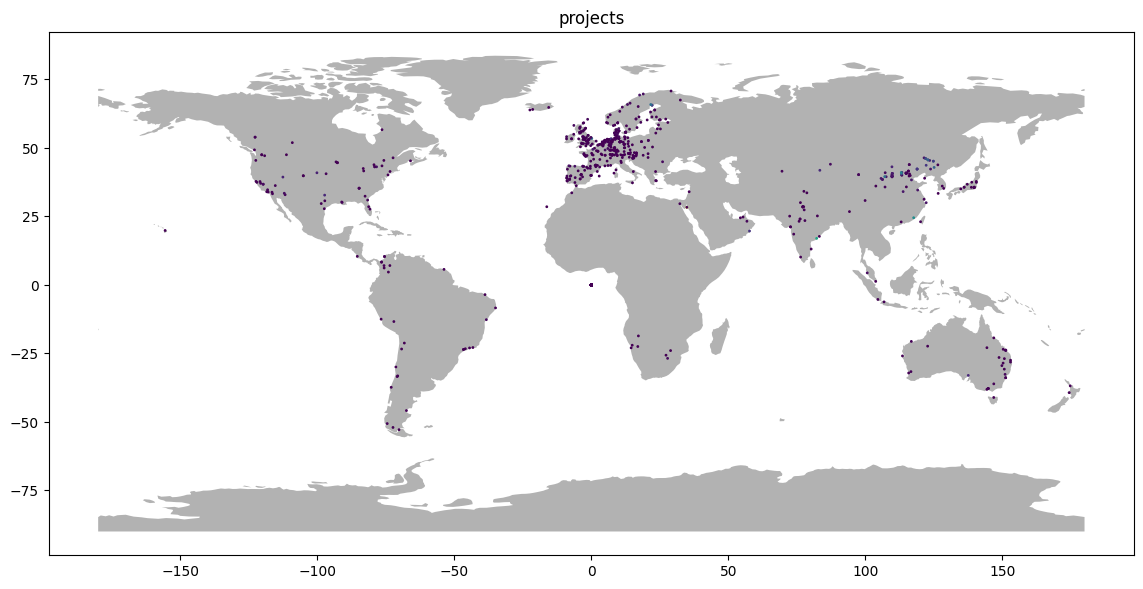

In [20]:

fig, ax = plt.subplots(figsize=(14, 10))
world.plot(ax=ax, alpha=0.6, color="grey")
geo_df.plot(column="IEA zero-carbon estimated normalized capacity [Nm³ H₂/hour]", ax=ax, markersize=1, legend=False)
plt.title("projects")

<Axes: >

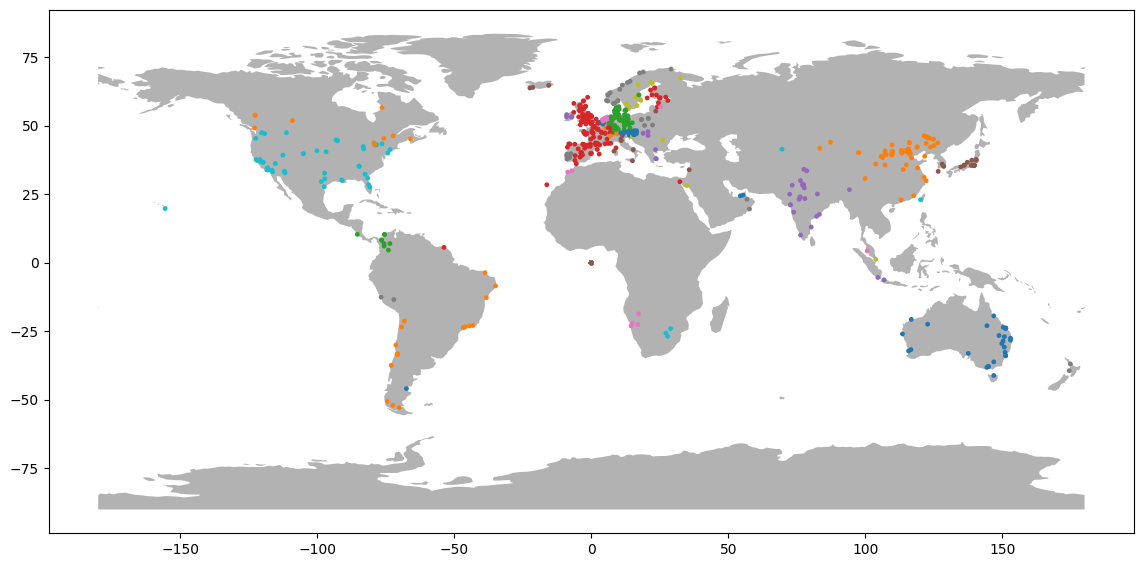

In [21]:
fig, ax = plt.subplots(figsize=(14, 10))
world.plot(ax=ax, alpha=0.6, color="grey")
geo_df.plot("Country", legend=False, ax=ax, markersize=6)


In [22]:
world = geopandas.read_file("../data/raw/Weltkugel/ne_10m_admin_0_countries.shp")

# fig, ax = plt.subplots(figsize=(14, 10))
# world.plot(ax=ax, alpha=0.6)
# #geo_df.plot(column="IEA zero-carbon estimated normalized capacity [Nm³ H₂/hour]", ax=ax, markersize=1, legend=False)



In [23]:
pd.set_option('display.max_columns', None)
world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,ADM0_A3,GEOU_DIF,GEOUNIT,GU_A3,SU_DIF,SUBUNIT,SU_A3,BRK_DIFF,NAME,NAME_LONG,BRK_A3,BRK_NAME,BRK_GROUP,ABBREV,POSTAL,FORMAL_EN,FORMAL_FR,NAME_CIAWF,NOTE_ADM0,NOTE_BRK,NAME_SORT,NAME_ALT,MAPCOLOR7,MAPCOLOR8,MAPCOLOR9,MAPCOLOR13,POP_EST,POP_RANK,POP_YEAR,GDP_MD,GDP_YEAR,ECONOMY,INCOME_GRP,FIPS_10,ISO_A2,ISO_A2_EH,ISO_A3,ISO_A3_EH,ISO_N3,ISO_N3_EH,UN_A3,WB_A2,WB_A3,WOE_ID,WOE_ID_EH,WOE_NOTE,ADM0_ISO,ADM0_DIFF,ADM0_TLC,ADM0_A3_US,ADM0_A3_FR,ADM0_A3_RU,ADM0_A3_ES,ADM0_A3_CN,ADM0_A3_TW,ADM0_A3_IN,ADM0_A3_NP,ADM0_A3_PK,ADM0_A3_DE,ADM0_A3_GB,ADM0_A3_BR,ADM0_A3_IL,ADM0_A3_PS,ADM0_A3_SA,ADM0_A3_EG,ADM0_A3_MA,ADM0_A3_PT,ADM0_A3_AR,ADM0_A3_JP,ADM0_A3_KO,ADM0_A3_VN,ADM0_A3_TR,ADM0_A3_ID,ADM0_A3_PL,ADM0_A3_GR,ADM0_A3_IT,ADM0_A3_NL,ADM0_A3_SE,ADM0_A3_BD,ADM0_A3_UA,ADM0_A3_UN,ADM0_A3_WB,CONTINENT,REGION_UN,SUBREGION,REGION_WB,NAME_LEN,LONG_LEN,ABBREV_LEN,TINY,HOMEPART,MIN_ZOOM,MIN_LABEL,MAX_LABEL,LABEL_X,LABEL_Y,NE_ID,WIKIDATAID,NAME_AR,NAME_BN,NAME_DE,NAME_EN,NAME_ES,NAME_FA,NAME_FR,NAME_EL,NAME_HE,NAME_HI,NAME_HU,NAME_ID,NAME_IT,NAME_JA,NAME_KO,NAME_NL,NAME_PL,NAME_PT,NAME_RU,NAME_SV,NAME_TR,NAME_UK,NAME_UR,NAME_VI,NAME_ZH,NAME_ZHT,FCLASS_ISO,TLC_DIFF,FCLASS_TLC,FCLASS_US,FCLASS_FR,FCLASS_RU,FCLASS_ES,FCLASS_CN,FCLASS_TW,FCLASS_IN,FCLASS_NP,FCLASS_PK,FCLASS_DE,FCLASS_GB,FCLASS_BR,FCLASS_IL,FCLASS_PS,FCLASS_SA,FCLASS_EG,FCLASS_MA,FCLASS_PT,FCLASS_AR,FCLASS_JP,FCLASS_KO,FCLASS_VN,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,0,2,Indonesia,IDN,0,2,Sovereign country,1,Indonesia,IDN,0,Indonesia,IDN,0,Indonesia,IDN,0,Indonesia,Indonesia,IDN,Indonesia,None,Indo.,INDO,Republic of Indonesia,None,Indonesia,None,None,Indonesia,None,6,6,6,11,2.71e+08,17,2019,1119190,2019,4. Emerging region: MIKT,4. Lower middle income,ID,ID,ID,IDN,IDN,360,360,360,ID,IDN,23424846,23424846,Exact WOE match as country,IDN,None,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,-99,-99,Asia,Asia,South-Eastern Asia,East Asia & Pacific,9,9,5,-99,1,0.0,1.7,6.7,101.89,-0.95,1159320845,Q252,إندونيسيا,ইন্দোনেশিয়া,Indonesien,Indonesia,Indonesia,اندونزی,Indonésie,Ινδονησία,אינדונזיה,इंडोनेशिया,Indonézia,Indonesia,Indonesia,インドネシア,인도네시아,Indonesië,Indonezja,Indonésia,Индонезия,Indonesien,Endonezya,Індонезія,انڈونیشیا,Indonesia,印度尼西亚,印度尼西亞,Admin-0 country,None,Admin-0 country,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,Admin-0 country,0,3,Malaysia,MYS,0,2,Sovereign country,1,Malaysia,MYS,0,Malaysia,MYS,0,Malaysia,MYS,0,Malaysia,Malaysia,MYS,Malaysia,None,Malay.,MY,Malaysia,None,Malaysia,None,None,Malaysia,None,2,4,3,6,3.19e+07,15,2019,364681,2019,6. Developing region,3. Upper middle income,MY,MY,MY,MYS,MYS,458,458,458,MY,MYS,23424901,23424901,Exact WOE match as country,MYS,None,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,-99,-99,Asia,Asia,South-Eastern Asia,East Asia & Pacific,8,8,6,-99,1,0.0,3.0,8.0,113.84,2.53,1159321083,Q833,ماليزيا,মালয়েশিয়া,Malaysia,Malaysia,Malasia,مالزی,Malaisie,Μαλαισία,מלזיה,मलेशिया,Malajzia,Malaysia,Malaysia,マレーシア,말레이시아,Maleisië,Malezja,Malásia,Малайзия,Malaysia,Malezya,Малайзія,ملائیشیا,Malaysia,马来西亚,馬來西亞,Admin-0 country,None,Admin-0 country,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,Admin-0 country,0,2,Chile,CHL,0,2,Sovereign country,1,Chile,CHL,0,Chile,CHL,0,Chile,CHL,0,Chile,Chile,CHL,Chile,None,Chile,CL,Republic of Chile,None,Chile,None,None,Chile,None,5,1,5,9,1.90e+07,14,2019,282318,2019,5. Emerging region: G20,3. Upper

In [24]:
# #df_g = world.merge(geo_df, how="left", left_on="ISO_A3", right_on="Country")
# #df_g = geopandas.GeoDataFrame(df_g, geometry="geometry")
# #df_g.head(5)


# #highlight_codes = ["DEU", "FRA", "ITA"]

# #ax = world.plot(color="lightgrey", edgecolor="black", figsize=(10, 6))

# #
# # world[world["ISO_A3"].isin(highlight_codes)].plot(ax=ax, color="blue")

# fig, ax = plt.subplots(figsize=(14, 10))
# #world.plot(color="lightgrey", edgecolor="black", ax=ax)
# geo_df.plot(ax=ax,
#     column="IEA zero-carbon estimated normalized capacity [Nm³ H₂/hour]",
#     cmap="OrRd",
#     legend=False,
#     missing_kwds={"color": "grey"}
# )
# fig

In [25]:

mask = df_real_techn.loc[:, 'Date online'] <= 2010
df_real_techn.loc[mask, :]

,Project name,Country,Date online,Decomission date,Status,Technology,Technology_details,Technology_electricity,Technology_electricity_details,Product,EndUse_Refining,EndUse_Ammonia,EndUse_Methanol,EndUse_Iron&Steel,EndUse_Other Ind,EndUse_Mobility,EndUse_Power,EndUse_Grid inj.,EndUse_CHP,EndUse_Domestic heat,EndUse_Biofuels,EndUse_Synfuels,EndUse_CH4 grid inj.,EndUse_CH4 mobility,Announced Size,Capacity_MWel,Capacity_Nm³ H₂/h,Capacity_kt H2/y,Capacity_t CO₂ captured/y,IEA zero-carbon estimated normalized capacity [Nm³ H₂/hour],References,Latitude,Longitude,Technology_aggregate,LOWE_CF
131,"Hazira, Reliance, back-up hydrogen supply",IND,2005.0,NaN,Operational,ALK,NaN,Other/Unknown,NaN,H2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,[248] [485] [710],0.00,0.00,Electrolysis,0.57
150,"HARP System, Bella Coola",CAN,2010.0,NaN,Operational,ALK,NaN,Other/unknown,NaN,H2,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3MW - 60 Nm3 H2/h,0.30,65.22,0.05,NaN,65.22,"[1], [5], [69]",0.00,0.00,Electrolysis,0.57
151,H2KT - Hydrogen Energy Storage in Nuuk,DNK,2010.0,NaN,Operational,ALK,NaN,Other/unknown,NaN,H2,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,19 Nm3 H2/h,0.09,19.00,0.01,NaN,19.00,"[1], [5] [409]",0.00,0.00,Electrolysis,0.57
152,ITHER,ESP,2010.0,NaN,DEMO,ALK,NaN,Other/unknown,NaN,H2,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065MW,0.07,14.13,0.01,NaN,14.13,[1] [2] [7] [64],0.00,0.00,Electrolysis,0.57
153,H2SusBuild,GRC,2010.0,NaN,DEMO,Other Electrolysis,Unknown PtX,Other/unknown,NaN,H2,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.022MW,0.22,48.89,0.04,NaN,48.89,[461],0.00,0.00,Electrolysis,0.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,18x180 kW projects in USA,USA,2000.0,NaN,Operational,PEM,NaN,Other/Unknown,NaN,H2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18x180kw,3.24,623.08,0.49,NaN,623.08,[1020],0.00,0.00,Electrolysis,0.57
792,12 x 120 kW projects in USA,USA,2000.0,NaN,Operational,PEM,NaN,Other/Unknown,NaN,H2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12x120kw,1.44,276.92,0.22,NaN,276.92,[1020],0.00,0.00,Electrolysis,0.57
982,Oskarshamn nuclear plant,SWE,1992.0,NaN,Operational,ALK,NaN,Nuclear,NaN,H2,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.7MW or 12 kg H2/h,0.70,152.17,0.12,NaN,152.17,[1221],57.42,16.67,Electrolysis,0.80
1339,"Plug Power Charleston, Tenesse (former United ...",USA,2008.0,NaN,Operational,PEM,NaN,Other/Unknown,NaN,H2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.5 t H2/d,15.82,3043.07,2.37,NaN,3043.07,[1665],35.29,-84.76,Electrolysis,0.57


In [26]:
#display(pd.crosstab(columns=df_real_techn["Country"], index=df_real_techn["IEA zero-carbon estimated normalized capacity [Nm³ H₂/hour]"]))

annual_prod = df_real_techn.groupby(["Date online", "Country"])["IEA zero-carbon estimated normalized capacity [Nm³ H₂/hour]"].sum()
annual_prod

Date online  Country
1965.0       PER          5434.78
1992.0       SWE           152.17
2000.0       ESP             0.19
             FRA             0.78
             NOR            10.87
                          ...    
2028.0       ROU         12222.22
2029.0       PRT          2444.44
2030.0       COL         10869.57
             GBR        173076.92
             NOR          4444.44
Name: IEA zero-carbon estimated normalized capacity [Nm³ H₂/hour], Length: 333, dtype: float64

<Axes: xlabel='Country'>

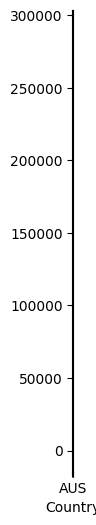

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
world.plot(ax=ax, alpha=0.6, color="grey")
annual_prod.loc[2025,].plot(legend=False, ax=ax, markersize=6)

#problem ist nun, dass die ländercodes natürlich mit nichts verknüpft sind, und demnach nicht eingezeichnet werden können

In [28]:

annual_prod.loc[(2025, )].loc["SGP",]

np.float64(4.681647940074907)

In [29]:
#mach leere spalte in kope von welt
#je jahr lade alle werte aus annual prod und pack sie in die leere spalte
#zeichne

#sonst: heatmap aller bisherigen jahre

world2 =  world
world2.loc[:, 'Production'] = ''
world2.head(5)

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,ADM0_A3,GEOU_DIF,GEOUNIT,GU_A3,SU_DIF,SUBUNIT,SU_A3,BRK_DIFF,NAME,NAME_LONG,BRK_A3,BRK_NAME,BRK_GROUP,ABBREV,POSTAL,FORMAL_EN,FORMAL_FR,NAME_CIAWF,NOTE_ADM0,NOTE_BRK,NAME_SORT,NAME_ALT,MAPCOLOR7,MAPCOLOR8,MAPCOLOR9,MAPCOLOR13,POP_EST,POP_RANK,POP_YEAR,GDP_MD,GDP_YEAR,ECONOMY,INCOME_GRP,FIPS_10,ISO_A2,ISO_A2_EH,ISO_A3,ISO_A3_EH,ISO_N3,ISO_N3_EH,UN_A3,WB_A2,WB_A3,WOE_ID,WOE_ID_EH,WOE_NOTE,ADM0_ISO,ADM0_DIFF,ADM0_TLC,ADM0_A3_US,ADM0_A3_FR,ADM0_A3_RU,ADM0_A3_ES,ADM0_A3_CN,ADM0_A3_TW,ADM0_A3_IN,ADM0_A3_NP,ADM0_A3_PK,ADM0_A3_DE,ADM0_A3_GB,ADM0_A3_BR,ADM0_A3_IL,ADM0_A3_PS,ADM0_A3_SA,ADM0_A3_EG,ADM0_A3_MA,ADM0_A3_PT,ADM0_A3_AR,ADM0_A3_JP,ADM0_A3_KO,ADM0_A3_VN,ADM0_A3_TR,ADM0_A3_ID,ADM0_A3_PL,ADM0_A3_GR,ADM0_A3_IT,ADM0_A3_NL,ADM0_A3_SE,ADM0_A3_BD,ADM0_A3_UA,ADM0_A3_UN,ADM0_A3_WB,CONTINENT,REGION_UN,SUBREGION,REGION_WB,NAME_LEN,LONG_LEN,ABBREV_LEN,TINY,HOMEPART,MIN_ZOOM,MIN_LABEL,MAX_LABEL,LABEL_X,LABEL_Y,NE_ID,WIKIDATAID,NAME_AR,NAME_BN,NAME_DE,NAME_EN,NAME_ES,NAME_FA,NAME_FR,NAME_EL,NAME_HE,NAME_HI,NAME_HU,NAME_ID,NAME_IT,NAME_JA,NAME_KO,NAME_NL,NAME_PL,NAME_PT,NAME_RU,NAME_SV,NAME_TR,NAME_UK,NAME_UR,NAME_VI,NAME_ZH,NAME_ZHT,FCLASS_ISO,TLC_DIFF,FCLASS_TLC,FCLASS_US,FCLASS_FR,FCLASS_RU,FCLASS_ES,FCLASS_CN,FCLASS_TW,FCLASS_IN,FCLASS_NP,FCLASS_PK,FCLASS_DE,FCLASS_GB,FCLASS_BR,FCLASS_IL,FCLASS_PS,FCLASS_SA,FCLASS_EG,FCLASS_MA,FCLASS_PT,FCLASS_AR,FCLASS_JP,FCLASS_KO,FCLASS_VN,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry,Production
0,Admin-0 country,0,2,Indonesia,IDN,0,2,Sovereign country,1,Indonesia,IDN,0,Indonesia,IDN,0,Indonesia,IDN,0,Indonesia,Indonesia,IDN,Indonesia,None,Indo.,INDO,Republic of Indonesia,None,Indonesia,None,None,Indonesia,None,6,6,6,11,2.71e+08,17,2019,1119190,2019,4. Emerging region: MIKT,4. Lower middle income,ID,ID,ID,IDN,IDN,360,360,360,ID,IDN,23424846,23424846,Exact WOE match as country,IDN,None,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,-99,-99,Asia,Asia,South-Eastern Asia,East Asia & Pacific,9,9,5,-99,1,0.0,1.7,6.7,101.89,-0.95,1159320845,Q252,إندونيسيا,ইন্দোনেশিয়া,Indonesien,Indonesia,Indonesia,اندونزی,Indonésie,Ινδονησία,אינדונזיה,इंडोनेशिया,Indonézia,Indonesia,Indonesia,インドネシア,인도네시아,Indonesië,Indonezja,Indonésia,Индонезия,Indonesien,Endonezya,Індонезія,انڈونیشیا,Indonesia,印度尼西亚,印度尼西亞,Admin-0 country,None,Admin-0 country,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4...",
1,Admin-0 country,0,3,Malaysia,MYS,0,2,Sovereign country,1,Malaysia,MYS,0,Malaysia,MYS,0,Malaysia,MYS,0,Malaysia,Malaysia,MYS,Malaysia,None,Malay.,MY,Malaysia,None,Malaysia,None,None,Malaysia,None,2,4,3,6,3.19e+07,15,2019,364681,2019,6. Developing region,3. Upper middle income,MY,MY,MY,MYS,MYS,458,458,458,MY,MYS,23424901,23424901,Exact WOE match as country,MYS,None,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,-99,-99,Asia,Asia,South-Eastern Asia,East Asia & Pacific,8,8,6,-99,1,0.0,3.0,8.0,113.84,2.53,1159321083,Q833,ماليزيا,মালয়েশিয়া,Malaysia,Malaysia,Malasia,مالزی,Malaisie,Μαλαισία,מלזיה,मलेशिया,Malajzia,Malaysia,Malaysia,マレーシア,말레이시아,Maleisië,Malezja,Malásia,Малайзия,Malaysia,Malezya,Малайзія,ملائیشیا,Malaysia,马来西亚,馬來西亞,Admin-0 country,None,Admin-0 country,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4...",
2,Admin-0 country,0,2,Chile,CHL,0,2,Sovereign country,1,Chile,CHL,0,Chile,CHL,0,Chile,CHL,0,Chile,Chile,CHL,Chile,None,Chile,CL,Republic of Chile,None,Chile,None,None,Chile,None,5,1,5,9,1.90e+07,14,2019,282318,2019,5. Emerging region:

In [30]:
country_codes = annual_prod[2025].index

for eintrag in country_codes:
    i = annual_prod.loc[(2025, )].loc[eintrag,]
    position = world2.index[world2["ISO_A3"] == eintrag]
    world2.loc[position, 'Production'] = i
    
world2

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,ADM0_A3,GEOU_DIF,GEOUNIT,GU_A3,SU_DIF,SUBUNIT,SU_A3,BRK_DIFF,NAME,NAME_LONG,BRK_A3,BRK_NAME,BRK_GROUP,ABBREV,POSTAL,FORMAL_EN,FORMAL_FR,NAME_CIAWF,NOTE_ADM0,NOTE_BRK,NAME_SORT,NAME_ALT,MAPCOLOR7,MAPCOLOR8,MAPCOLOR9,MAPCOLOR13,POP_EST,POP_RANK,POP_YEAR,GDP_MD,GDP_YEAR,ECONOMY,INCOME_GRP,FIPS_10,ISO_A2,ISO_A2_EH,ISO_A3,ISO_A3_EH,ISO_N3,ISO_N3_EH,UN_A3,WB_A2,WB_A3,WOE_ID,WOE_ID_EH,WOE_NOTE,ADM0_ISO,ADM0_DIFF,ADM0_TLC,ADM0_A3_US,ADM0_A3_FR,ADM0_A3_RU,ADM0_A3_ES,ADM0_A3_CN,ADM0_A3_TW,ADM0_A3_IN,ADM0_A3_NP,ADM0_A3_PK,ADM0_A3_DE,ADM0_A3_GB,ADM0_A3_BR,ADM0_A3_IL,ADM0_A3_PS,ADM0_A3_SA,ADM0_A3_EG,ADM0_A3_MA,ADM0_A3_PT,ADM0_A3_AR,ADM0_A3_JP,ADM0_A3_KO,ADM0_A3_VN,ADM0_A3_TR,ADM0_A3_ID,ADM0_A3_PL,ADM0_A3_GR,ADM0_A3_IT,ADM0_A3_NL,ADM0_A3_SE,ADM0_A3_BD,ADM0_A3_UA,ADM0_A3_UN,ADM0_A3_WB,CONTINENT,REGION_UN,SUBREGION,REGION_WB,NAME_LEN,LONG_LEN,ABBREV_LEN,TINY,HOMEPART,MIN_ZOOM,MIN_LABEL,MAX_LABEL,LABEL_X,LABEL_Y,NE_ID,WIKIDATAID,NAME_AR,NAME_BN,NAME_DE,NAME_EN,NAME_ES,NAME_FA,NAME_FR,NAME_EL,NAME_HE,NAME_HI,NAME_HU,NAME_ID,NAME_IT,NAME_JA,NAME_KO,NAME_NL,NAME_PL,NAME_PT,NAME_RU,NAME_SV,NAME_TR,NAME_UK,NAME_UR,NAME_VI,NAME_ZH,NAME_ZHT,FCLASS_ISO,TLC_DIFF,FCLASS_TLC,FCLASS_US,FCLASS_FR,FCLASS_RU,FCLASS_ES,FCLASS_CN,FCLASS_TW,FCLASS_IN,FCLASS_NP,FCLASS_PK,FCLASS_DE,FCLASS_GB,FCLASS_BR,FCLASS_IL,FCLASS_PS,FCLASS_SA,FCLASS_EG,FCLASS_MA,FCLASS_PT,FCLASS_AR,FCLASS_JP,FCLASS_KO,FCLASS_VN,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry,Production
0,Admin-0 country,0,2,Indonesia,IDN,0,2,Sovereign country,1,Indonesia,IDN,0,Indonesia,IDN,0,Indonesia,IDN,0,Indonesia,Indonesia,IDN,Indonesia,None,Indo.,INDO,Republic of Indonesia,None,Indonesia,None,None,Indonesia,None,6,6,6,11,2.71e+08,17,2019,1119190,2019,4. Emerging region: MIKT,4. Lower middle income,ID,ID,ID,IDN,IDN,360,360,360,ID,IDN,23424846,23424846,Exact WOE match as country,IDN,None,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,-99,-99,Asia,Asia,South-Eastern Asia,East Asia & Pacific,9,9,5,-99,1,0.0,1.7,6.7,101.89,-0.95,1159320845,Q252,إندونيسيا,ইন্দোনেশিয়া,Indonesien,Indonesia,Indonesia,اندونزی,Indonésie,Ινδονησία,אינדונזיה,इंडोनेशिया,Indonézia,Indonesia,Indonesia,インドネシア,인도네시아,Indonesië,Indonezja,Indonésia,Индонезия,Indonesien,Endonezya,Індонезія,انڈونیشیا,Indonesia,印度尼西亚,印度尼西亞,Admin-0 country,None,Admin-0 country,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4...",
1,Admin-0 country,0,3,Malaysia,MYS,0,2,Sovereign country,1,Malaysia,MYS,0,Malaysia,MYS,0,Malaysia,MYS,0,Malaysia,Malaysia,MYS,Malaysia,None,Malay.,MY,Malaysia,None,Malaysia,None,None,Malaysia,None,2,4,3,6,3.19e+07,15,2019,364681,2019,6. Developing region,3. Upper middle income,MY,MY,MY,MYS,MYS,458,458,458,MY,MYS,23424901,23424901,Exact WOE match as country,MYS,None,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,-99,-99,Asia,Asia,South-Eastern Asia,East Asia & Pacific,8,8,6,-99,1,0.0,3.0,8.0,113.84,2.53,1159321083,Q833,ماليزيا,মালয়েশিয়া,Malaysia,Malaysia,Malasia,مالزی,Malaisie,Μαλαισία,מלזיה,मलेशिया,Malajzia,Malaysia,Malaysia,マレーシア,말레이시아,Maleisië,Malezja,Malásia,Малайзия,Malaysia,Malezya,Малайзія,ملائیشیا,Malaysia,马来西亚,馬來西亞,Admin-0 country,None,Admin-0 country,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4...",
2,Admin-0 country,0,2,Chile,CHL,0,2,Sovereign country,1,Chile,CHL,0,Chile,CHL,0,Chile,CHL,0,Chile,Chile,CHL,Chile,None,Chile,CL,Republic of Chile,None,Chile,None,None,Chile,None,5,1,5,9,1.90e+07,14,2019,282318,2019,5. Emerging region:

<Axes: >

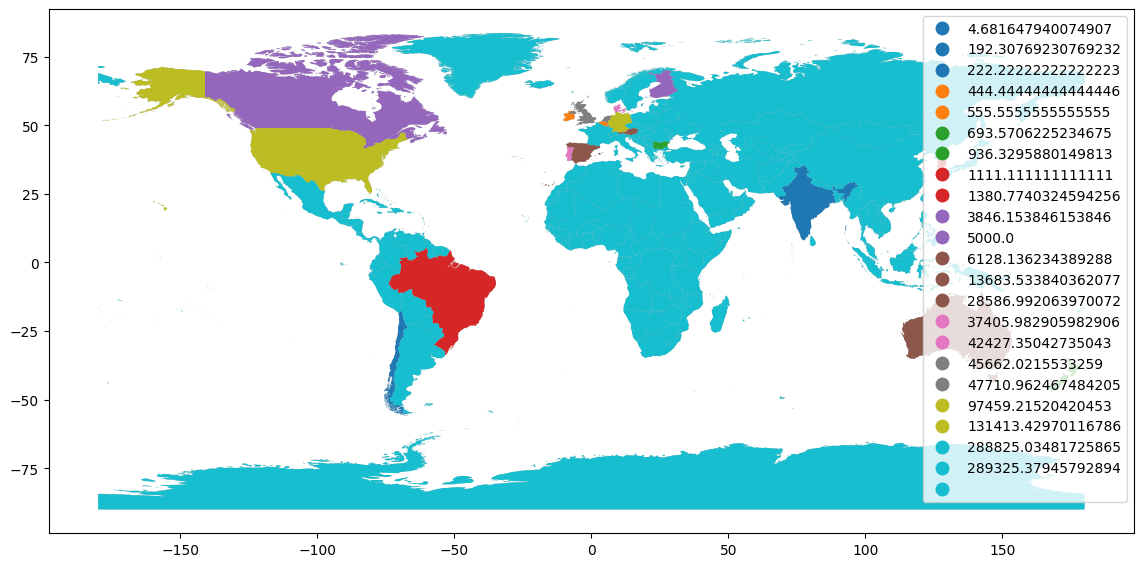

In [31]:
fig, ax = plt.subplots(figsize=(14, 10))
world2.plot(ax=ax, alpha=0.6, color="grey")
world2.plot("Production", legend=True, ax=ax)


In [47]:
country_codes = annual_prod[2025].index

for eintrag in country_codes:
    i = annual_prod.loc[(2025, )].loc[eintrag,]
    position = world2.index[world2["ISO_A3"] == eintrag]
    world2.loc[position, 'Production'] = i
    
for i in world2["Production"]:
    if i == "":
        world2["Production"] = np.nan

world2.head(5)

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,ADM0_A3,GEOU_DIF,GEOUNIT,GU_A3,SU_DIF,SUBUNIT,SU_A3,BRK_DIFF,NAME,NAME_LONG,BRK_A3,BRK_NAME,BRK_GROUP,ABBREV,POSTAL,FORMAL_EN,FORMAL_FR,NAME_CIAWF,NOTE_ADM0,NOTE_BRK,NAME_SORT,NAME_ALT,MAPCOLOR7,MAPCOLOR8,MAPCOLOR9,MAPCOLOR13,POP_EST,POP_RANK,POP_YEAR,GDP_MD,GDP_YEAR,ECONOMY,INCOME_GRP,FIPS_10,ISO_A2,ISO_A2_EH,ISO_A3,ISO_A3_EH,ISO_N3,ISO_N3_EH,UN_A3,WB_A2,WB_A3,WOE_ID,WOE_ID_EH,WOE_NOTE,ADM0_ISO,ADM0_DIFF,ADM0_TLC,ADM0_A3_US,ADM0_A3_FR,ADM0_A3_RU,ADM0_A3_ES,ADM0_A3_CN,ADM0_A3_TW,ADM0_A3_IN,ADM0_A3_NP,ADM0_A3_PK,ADM0_A3_DE,ADM0_A3_GB,ADM0_A3_BR,ADM0_A3_IL,ADM0_A3_PS,ADM0_A3_SA,ADM0_A3_EG,ADM0_A3_MA,ADM0_A3_PT,ADM0_A3_AR,ADM0_A3_JP,ADM0_A3_KO,ADM0_A3_VN,ADM0_A3_TR,ADM0_A3_ID,ADM0_A3_PL,ADM0_A3_GR,ADM0_A3_IT,ADM0_A3_NL,ADM0_A3_SE,ADM0_A3_BD,ADM0_A3_UA,ADM0_A3_UN,ADM0_A3_WB,CONTINENT,REGION_UN,SUBREGION,REGION_WB,NAME_LEN,LONG_LEN,ABBREV_LEN,TINY,HOMEPART,MIN_ZOOM,MIN_LABEL,MAX_LABEL,LABEL_X,LABEL_Y,NE_ID,WIKIDATAID,NAME_AR,NAME_BN,NAME_DE,NAME_EN,NAME_ES,NAME_FA,NAME_FR,NAME_EL,NAME_HE,NAME_HI,NAME_HU,NAME_ID,NAME_IT,NAME_JA,NAME_KO,NAME_NL,NAME_PL,NAME_PT,NAME_RU,NAME_SV,NAME_TR,NAME_UK,NAME_UR,NAME_VI,NAME_ZH,NAME_ZHT,FCLASS_ISO,TLC_DIFF,FCLASS_TLC,FCLASS_US,FCLASS_FR,FCLASS_RU,FCLASS_ES,FCLASS_CN,FCLASS_TW,FCLASS_IN,FCLASS_NP,FCLASS_PK,FCLASS_DE,FCLASS_GB,FCLASS_BR,FCLASS_IL,FCLASS_PS,FCLASS_SA,FCLASS_EG,FCLASS_MA,FCLASS_PT,FCLASS_AR,FCLASS_JP,FCLASS_KO,FCLASS_VN,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry,Production
0,Admin-0 country,0,2,Indonesia,IDN,0,2,Sovereign country,1,Indonesia,IDN,0,Indonesia,IDN,0,Indonesia,IDN,0,Indonesia,Indonesia,IDN,Indonesia,None,Indo.,INDO,Republic of Indonesia,None,Indonesia,None,None,Indonesia,None,6,6,6,11,2.71e+08,17,2019,1119190,2019,4. Emerging region: MIKT,4. Lower middle income,ID,ID,ID,IDN,IDN,360,360,360,ID,IDN,23424846,23424846,Exact WOE match as country,IDN,None,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,IDN,-99,-99,Asia,Asia,South-Eastern Asia,East Asia & Pacific,9,9,5,-99,1,0.0,1.7,6.7,101.89,-0.95,1159320845,Q252,إندونيسيا,ইন্দোনেশিয়া,Indonesien,Indonesia,Indonesia,اندونزی,Indonésie,Ινδονησία,אינדונזיה,इंडोनेशिया,Indonézia,Indonesia,Indonesia,インドネシア,인도네시아,Indonesië,Indonezja,Indonésia,Индонезия,Indonesien,Endonezya,Індонезія,انڈونیشیا,Indonesia,印度尼西亚,印度尼西亞,Admin-0 country,None,Admin-0 country,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4...",NaN
1,Admin-0 country,0,3,Malaysia,MYS,0,2,Sovereign country,1,Malaysia,MYS,0,Malaysia,MYS,0,Malaysia,MYS,0,Malaysia,Malaysia,MYS,Malaysia,None,Malay.,MY,Malaysia,None,Malaysia,None,None,Malaysia,None,2,4,3,6,3.19e+07,15,2019,364681,2019,6. Developing region,3. Upper middle income,MY,MY,MY,MYS,MYS,458,458,458,MY,MYS,23424901,23424901,Exact WOE match as country,MYS,None,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,MYS,-99,-99,Asia,Asia,South-Eastern Asia,East Asia & Pacific,8,8,6,-99,1,0.0,3.0,8.0,113.84,2.53,1159321083,Q833,ماليزيا,মালয়েশিয়া,Malaysia,Malaysia,Malasia,مالزی,Malaisie,Μαλαισία,מלזיה,मलेशिया,Malajzia,Malaysia,Malaysia,マレーシア,말레이시아,Maleisië,Malezja,Malásia,Малайзия,Malaysia,Malezya,Малайзія,ملائیشیا,Malaysia,马来西亚,馬來西亞,Admin-0 country,None,Admin-0 country,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4...",NaN
2,Admin-0 country,0,2,Chile,CHL,0,2,Sovereign country,1,Chile,CHL,0,Chile,CHL,0,Chile,CHL,0,Chile,Chile,CHL,Chile,None,Chile,CL,Republic of Chile,None,Chile,None,None,Chile,None,5,1,5,9,1.90e+07,14,2019,282318,2019,5. Emerging r

<Axes: >

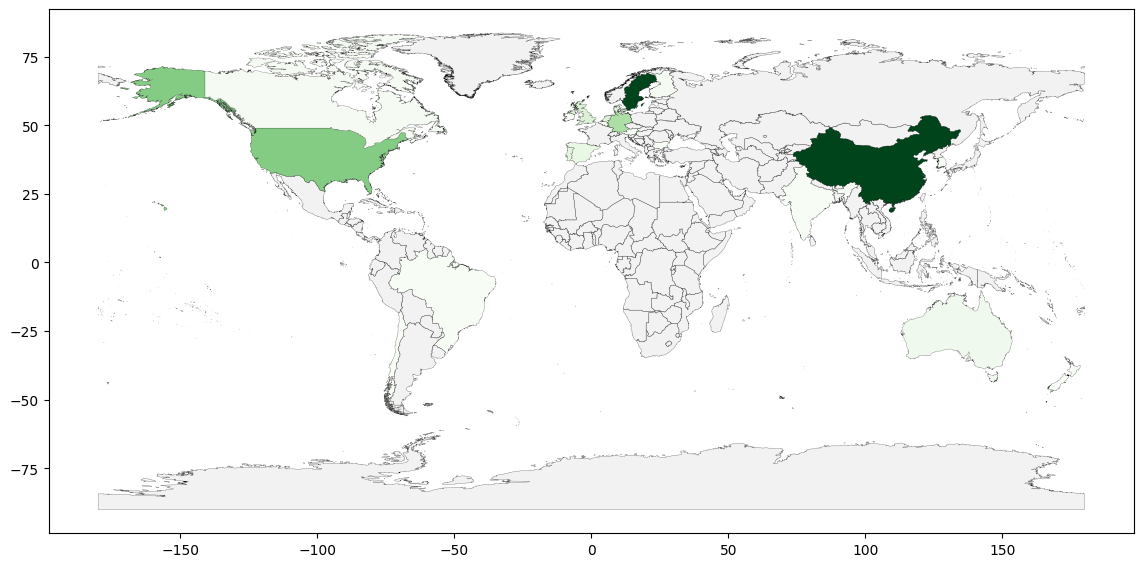

In [62]:
world2["geometry"] = world2.buffer(0)
fig, ax = plt.subplots(figsize=(14, 10))
world2.plot(ax=ax, alpha=0.1, color="grey", edgecolor="black", linewidth=0.5)
world2.plot("Production", ax=ax, cmap="Greens", edgecolor="black", linewidth=0.1, legend=False, missing_kwds={"color": "none"})
